# This would be the file to do analysis on how hiring timeline has changed for bif vs. small companies post AI

In [195]:
## first, importing the basic libraries!
from pytrends.request import TrendReq
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import statsmodels.api as sm
from glob import glob
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import linregress


In [122]:
## now adding csv files
monthly_postings = pd.read_csv("CSV_files/postings_combined.csv")
count_df = pd.read_csv("CSV_files/wf_count.csv", 
                       usecols=['company', 'month', 'count', 'rcid'],
                       dtype={'count': 'float32', 'company': 'category'})

print("count_df loaded:", count_df.shape)

count_df loaded: (10239812, 4)


In [123]:
print("monthly_postings loaded:", monthly_postings.shape)
print("count_df loaded:", count_df.shape)

monthly_postings loaded: (1103593, 21)
count_df loaded: (10239812, 4)


In [124]:
# Create 'month' column from post_date (this is the key fix)
monthly_postings['month'] = pd.to_datetime(monthly_postings['post_date'], errors='coerce').dt.strftime('%Y-%m')
print(monthly_postings.head())


       job_id    rcid           company                         rics_k50  \
0  4029671745  350953   Microsoft Corp.  Information Technology Services   
1  3442789037  341560  Activision, Inc.          Media and Entertainment   
2  3974963511  350953   Microsoft Corp.  Information Technology Services   
3  4052300060  350953   Microsoft Corp.  Information Technology Services   
4  3720377867  350953   Microsoft Corp.  Information Technology Services   

                               rics_k200  \
0    Enterprise Software and IT Services   
1  Video Game Development and Publishing   
2    Enterprise Software and IT Services   
3    Enterprise Software and IT Services   
4    Enterprise Software and IT Services   

                                rics_k400  \
0  Enterprise Software and Cloud Services   
1   Video Game Development and Publishing   
2  Enterprise Software and Cloud Services   
3  Enterprise Software and Cloud Services   
4  Enterprise Software and Cloud Services   

       

In [125]:
# 1. Monthly aggregation (on a separate copy)
count_monthly = count_df.copy()

monthly_total = count_monthly.groupby(['month', 'company'])['count'].sum().reset_index()

# Convert to datetime for proper plotting
monthly_total['date'] = pd.to_datetime(monthly_total['month'] + '-01')

print("✅ Monthly aggregation ready")
print("Shape:", monthly_total.shape)

✅ Monthly aggregation ready
Shape: (1484, 4)


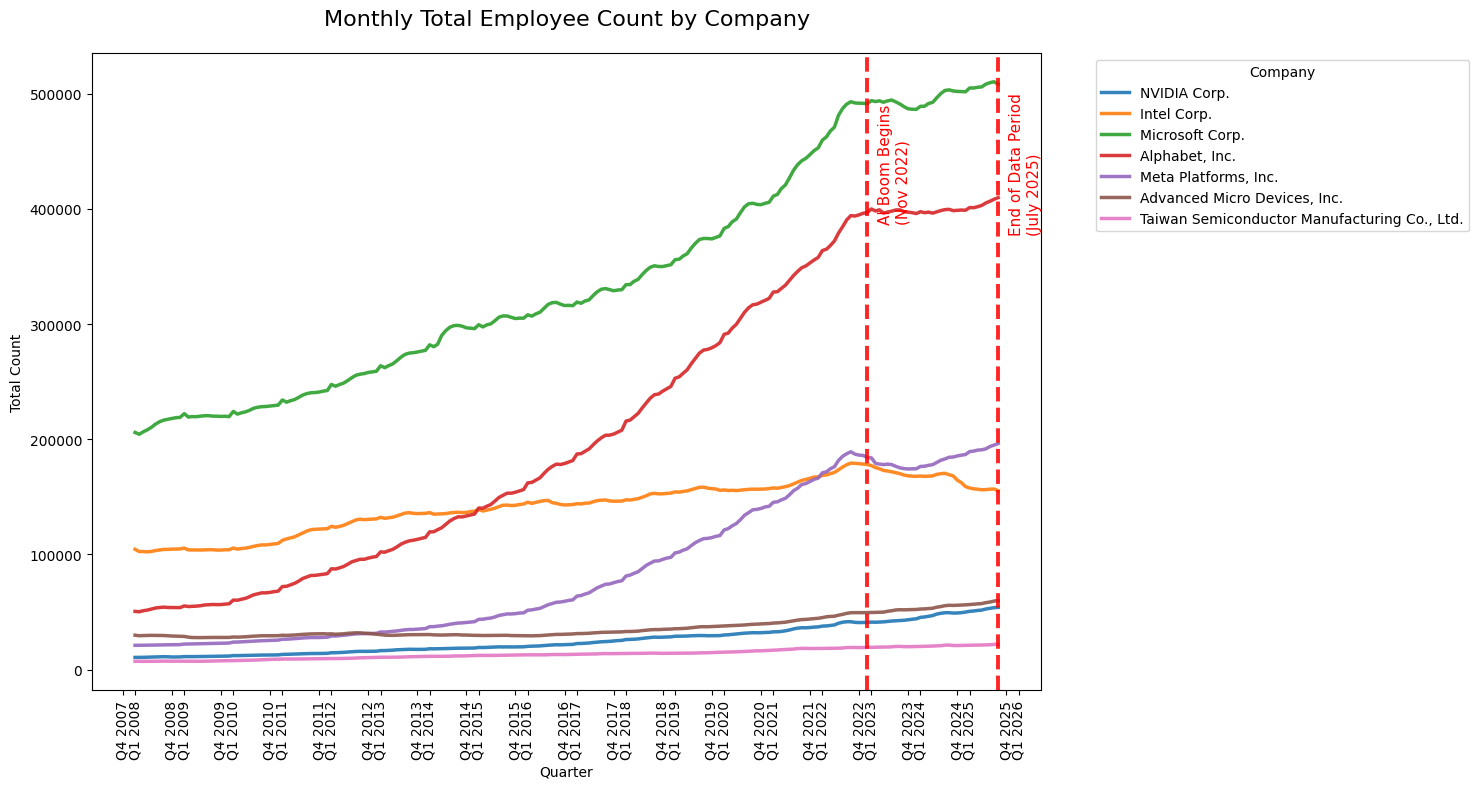

In [126]:
plt.figure(figsize=(15, 8))

sns.lineplot(
    data=monthly_total,
    x='date',
    y='count',
    hue='company',
    linewidth=2.5,
    marker=None,
    alpha=0.9
)

ax = plt.gca()

# Red line 1: AI Boom - November 2022
ax.axvline(x=pd.to_datetime('2022-11-30'), 
           color='red', linestyle='--', linewidth=2.8, alpha=0.85)
ax.annotate('AI Boom Begins\n(Nov 2022)', 
            xy=(pd.to_datetime('2022-11-30'), ax.get_ylim()[1] * 0.82),
            xytext=(8, 0), textcoords='offset points',
            fontsize=11, color='red', ha='left', va='center',
            rotation=90)

# Red line 2: End of Data Period - July 2025
ax.axvline(x=pd.to_datetime('2025-07-31'), 
           color='red', linestyle='--', linewidth=2.8, alpha=0.85)
ax.annotate('End of Data Period\n(July 2025)', 
            xy=(pd.to_datetime('2025-07-31'), ax.get_ylim()[1] * 0.82),
            xytext=(8, 0), textcoords='offset points',
            fontsize=11, color='red', ha='left', va='center',
            rotation=90)

# === Quarterly labels on x-axis ===
def quarter_formatter(x, pos):
    dt = mdates.num2date(x)
    year = dt.year
    quarter = (dt.month - 1) // 3 + 1
    return f'Q{quarter} {year}'

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 10]))
ax.xaxis.set_major_formatter(FuncFormatter(quarter_formatter))

plt.xticks(rotation=90)

plt.title("Monthly Total Employee Count by Company", fontsize=16, pad=20)
plt.xlabel("Quarter")
plt.ylabel("Total Count")
plt.legend(title="Company", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [127]:
# 1. Aggregate count_df to get TOTAL headcount per company per month
count_agg = count_df.groupby(['rcid', 'month'])['count'].sum().reset_index(name='total_count')

print("✅ count_df aggregated")
print("Shape of count_agg:", count_agg.shape)

✅ count_df aggregated
Shape of count_agg: (1484, 3)


In [128]:
# === Aggregate total postings per company per month ===
postings_agg = monthly_postings.groupby(['rcid', 'company', 'month']).size().reset_index(name='num_postings')


In [129]:
print(postings_agg.head())

    rcid                         company    month  num_postings
0      7                    Cameyo, Inc.  2023-01             1
1  17805  Granulate Cloud Solutions Ltd.  2022-11             6
2  17805  Granulate Cloud Solutions Ltd.  2022-12             4
3  17805  Granulate Cloud Solutions Ltd.  2023-01             2
4  17805  Granulate Cloud Solutions Ltd.  2023-03             1


In [130]:
# 3. Now join the two clean aggregates
merged_df = pd.merge(
    postings_agg,
    count_agg,
    on=['rcid', 'month'],
    how='inner'
)

print("\n✅ Final merged dataframe ready!")
print("Shape:", merged_df.shape)
print("Columns:", merged_df.columns.tolist())
print("\nFirst 5 rows:")
print(merged_df.head())


✅ Final merged dataframe ready!
Shape: (216, 5)
Columns: ['rcid', 'company', 'month', 'num_postings', 'total_count']

First 5 rows:
     rcid          company    month  num_postings   total_count
0  350953  Microsoft Corp.  2022-11         28811  491628.09375
1  350953  Microsoft Corp.  2022-12         28781  491256.46875
2  350953  Microsoft Corp.  2023-01         23008  493947.90625
3  350953  Microsoft Corp.  2023-02          6108  493159.87500
4  350953  Microsoft Corp.  2023-03          3863  493780.09375


In [131]:
merged_df['company'].unique()

<StringArray>
[                             'Microsoft Corp.',
                               'Alphabet, Inc.',
                                 'NVIDIA Corp.',
                         'Meta Platforms, Inc.',
                 'Advanced Micro Devices, Inc.',
                                  'Intel Corp.',
 'Taiwan Semiconductor Manufacturing Co., Ltd.']
Length: 7, dtype: str

In [132]:
merged_df['month'] = pd.to_datetime(merged_df['month'], errors='coerce')

In [133]:
print("\nUnique companies in merged data:", merged_df['company'].unique())


Unique companies in merged data: <StringArray>
[                             'Microsoft Corp.',
                               'Alphabet, Inc.',
                                 'NVIDIA Corp.',
                         'Meta Platforms, Inc.',
                 'Advanced Micro Devices, Inc.',
                                  'Intel Corp.',
 'Taiwan Semiconductor Manufacturing Co., Ltd.']
Length: 7, dtype: str


In [134]:
print(merged_df['company'].unique())

<StringArray>
[                             'Microsoft Corp.',
                               'Alphabet, Inc.',
                                 'NVIDIA Corp.',
                         'Meta Platforms, Inc.',
                 'Advanced Micro Devices, Inc.',
                                  'Intel Corp.',
 'Taiwan Semiconductor Manufacturing Co., Ltd.']
Length: 7, dtype: str


In [135]:
## creating ATF column
monthly_postings['post_date'] = pd.to_datetime(monthly_postings['post_date'])
monthly_postings['remove_date'] = pd.to_datetime(monthly_postings['remove_date'])
monthly_postings['filling_time_months'] = (monthly_postings['remove_date'] - monthly_postings['post_date']).dt.days / 30.44

In [136]:
# Calculate total postings per month across the 7 companies
monthly_total = merged_df.groupby('month')['num_postings'].sum().reset_index(name='total_postings')

# Merge and calculate portion
plot_df = merged_df.merge(monthly_total, on='month')
plot_df['portion'] = plot_df['num_postings'] / plot_df['total_postings']

# Safe date conversion
plot_df['date'] = pd.to_datetime(plot_df['month'].astype(str) + '-01')

/var/folders/fc/1ht7kmfs0_56nvwc76srygf80000gn/T/ipykernel_39518/3345446298.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/var/folders/fc/1ht7kmfs0_56nvwc76srygf80000gn/T/ipykernel_39518/3345446298.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right')


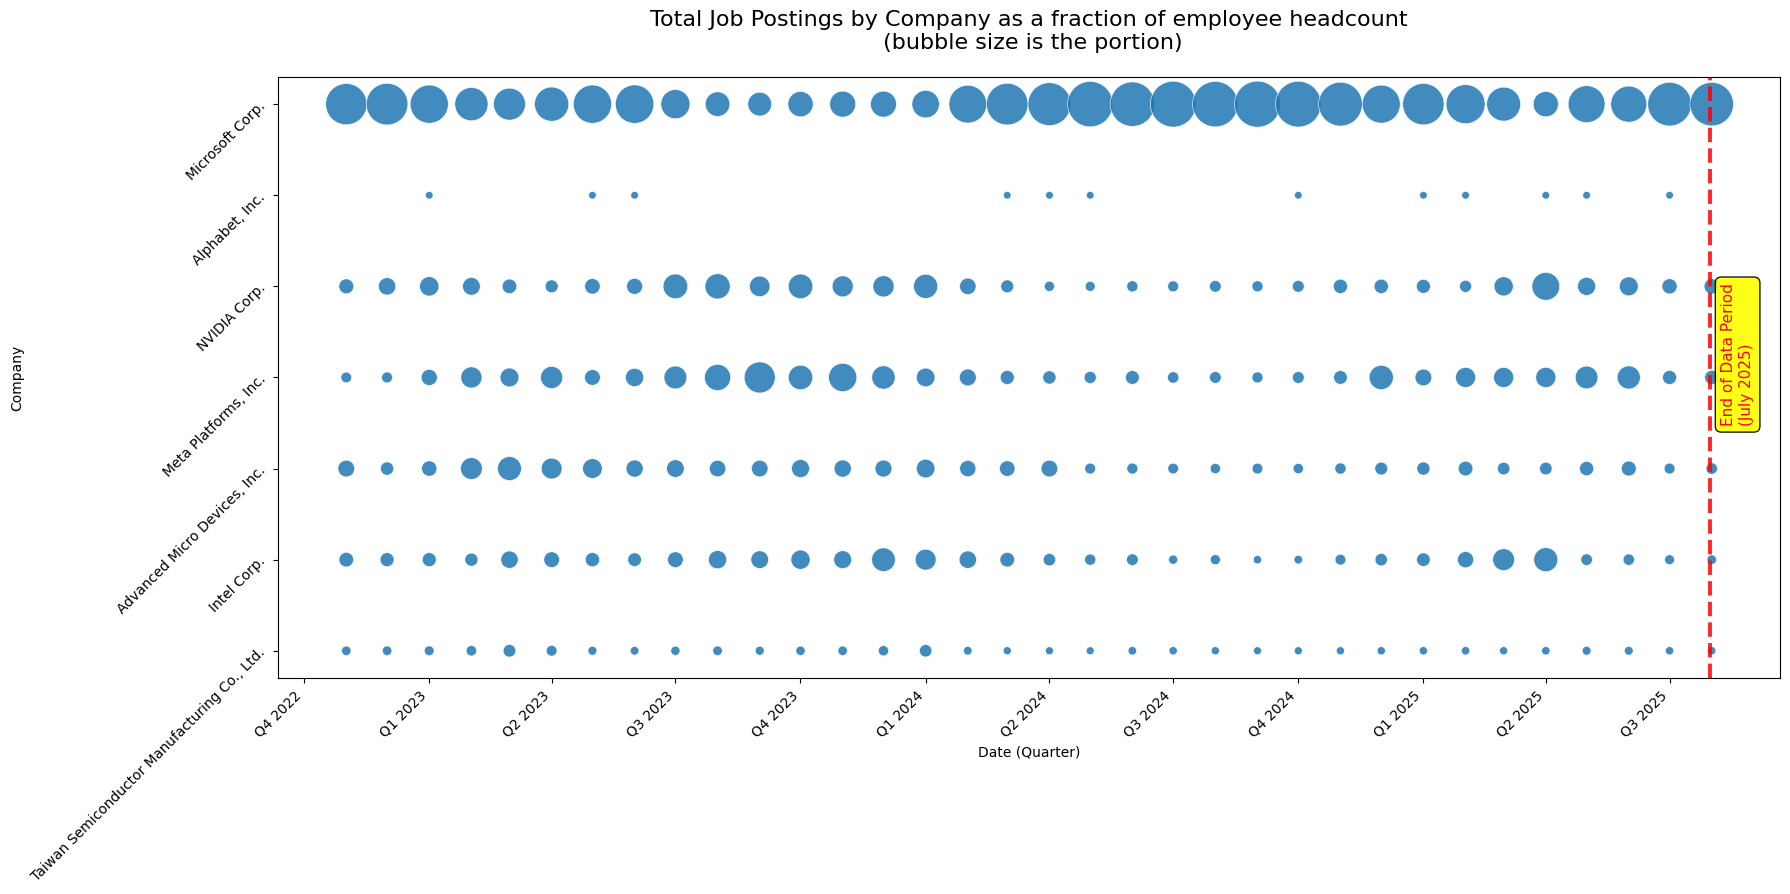

In [137]:
# Bubble plot with legend on the side
plt.figure(figsize=(18, 9))

sns.scatterplot(
    data=plot_df,
    x='date',
    y='company',
    size='portion',
    sizes=(30, 1100),
    alpha=0.85,
    palette="tab10",
    legend=False          # Turn off automatic legend here
)

ax = plt.gca()

# End of Data Period line
ax.axvline(x=pd.to_datetime('2025-07-31'), color='red', linestyle='--', linewidth=2.8, alpha=0.85)
ax.annotate('End of Data Period\n(July 2025)', 
            xy=(pd.to_datetime('2025-07-31'), 3.5),
            xytext=(8, 0), textcoords='offset points',
            fontsize=11, color='red', rotation=90,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="yellow", alpha=0.9))

# Quarterly labels on x-axis
def quarter_formatter(x, pos):
    dt = mdates.num2date(x)
    q = (dt.month - 1) // 3 + 1
    return f'Q{q} {dt.year}'

ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(FuncFormatter(quarter_formatter))
plt.xticks(rotation=45, ha='right')

plt.title("Total Job Postings by Company as a fraction of employee headcount\n (bubble size is the portion)", fontsize=16, pad=20)
plt.xlabel("Date (Quarter)")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

In [138]:
# === Corrected Merge: monthly_postings + count_agg on rcid + month ===
total_df = pd.merge(
    monthly_postings,
    count_agg,          # only the headcount column
    on=['rcid', 'month'],                           # ← this is the change you asked for
    how='left'                                      # keep ALL rows from monthly_postings
)

# Rename the headcount column cleanly
total_df = total_df.rename(columns={'count': 'total_headcount'})

# Optional: drop the duplicate rcid if it exists
if 'rcid_x' in total_df.columns or 'rcid_y' in total_df.columns:
    total_df = total_df.drop(columns=['rcid_y'], errors='ignore')
    total_df = total_df.rename(columns={'rcid_x': 'rcid'})

print("✅ Merged dataframe created (rcid + month join)!")
print("Shape:", total_df.shape)
print("Columns:", total_df.columns.tolist())
display(total_df.head())

✅ Merged dataframe created (rcid + month join)!
Shape: (1103593, 24)
Columns: ['job_id', 'rcid', 'company', 'rics_k50', 'rics_k200', 'rics_k400', 'title_raw', 'title_translated', 'role_k10', 'role_k50', 'role_k150', 'role_k1500', 'mapped_role', 'country', 'state', 'salary', 'post_date', 'remove_date', 'ultimate_parent_rcid', 'ultimate_parent_company_name', 'remote_type', 'month', 'filling_time_months', 'total_count']


,job_id,rcid,company,rics_k50,rics_k200,rics_k400,title_raw,title_translated,role_k10,role_k50,...,state,salary,post_date,remove_date,ultimate_parent_rcid,ultimate_parent_company_name,remote_type,month,filling_time_months,total_count
0,4029671745,350953,Microsoft Corp.,Information Technology Services,Enterprise Software and IT Services,Enterprise Software and Cloud Services,Sr Program Manager,sr program manager,Software Engineer,Software Developer,...,Meghalaya,43814.079696,2024-09-18,2024-10-09,350953,Microsoft Corp.,Fully in Office,2024-09,0.689882,502360.84375
1,3442789037,341560,"Activision, Inc.",Media and Entertainment,Video Game Development and Publishing,Video Game Development and Publishing,Staff Data Scientist - Activision Blizzard Media,staff data scientist activision blizzard media,Sales and Marketing,Product Marketing,...,California,207139.142406,2023-01-17,2023-01-20,350953,Microsoft Corp.,Fully in Office,2023-01,0.098555,NaN
2,3974963511,350953,Microsoft Corp.,Information Technology Services,Enterprise Software and IT Services,Enterprise Software and Cloud Services,Azure Business Value & Cloud Economics Specialist,azure business value and cloud economics spe...,Software Engineer,Software Developer,...,California,178700.000000,2024-07-12,2024-08-11,350953,Microsoft Corp.,Fully in Office,2024-07,0.985545,502770.34375
3,4052300060,350953,Microsoft Corp.,Information Technology Services,Enterprise Software and IT Services,Enterprise Software and Cloud Services,Sr Data Analyst,sr data analyst,Project and IT Specialist,Data Analyst,...,Mizoram,16304.345810,2024-10-15,2024-11-14,350953,Microsoft Corp.,Fully in Office,2024-10,0.985545,501940.75000
4,3720377867,350953,Microsoft Corp.,Information Technology Services,Enterprise Software and IT Services,Enterprise Software and Cloud Services,Principal Hardware Engineering Manager,principal hardware engineering manager,Software Engineer,Software Developer,...,California,252191.686244,2023-09-21,2023-10-06,350953,Microsoft Corp.,Fully in Office,2023-09,0.492773,488714.21875


In [148]:
# Recreate company_monthly_avg with Avg_time_to_fill + total_postings
company_monthly_avg = (
    monthly_postings
    .groupby(['month', 'ultimate_parent_rcid', 'ultimate_parent_company_name'])
    .agg(
        Avg_time_to_fill=('filling_time_months', 'mean'),
        total_postings=('job_id', 'count')          # total number of job postings this month
    )
    .reset_index()
)

print("✅ company_monthly_avg recreated with total_postings!")
print("Shape:", company_monthly_avg.shape)
display(company_monthly_avg.head())

✅ company_monthly_avg recreated with total_postings!
Shape: (245, 5)


,month,ultimate_parent_rcid,ultimate_parent_company_name,Avg_time_to_fill,total_postings
0,2022-11,350953,Microsoft Corp.,0.299909,35084
1,2022-11,766823,"Alphabet, Inc.",0.287791,9610
2,2022-11,1223555,NVIDIA Corp.,0.352224,2943
3,2022-11,1233178,"Meta Platforms, Inc.",0.737707,1086
4,2022-11,1292281,"Advanced Micro Devices, Inc.",0.287050,4096


In [150]:
# Merge with headcount from count_agg
total_df = pd.merge(
    company_monthly_avg,
    count_agg[['rcid', 'month', 'total_count']],
    left_on=['ultimate_parent_rcid', 'month'],
    right_on=['rcid', 'month'],
    how='left'
)

total_df = total_df.rename(columns={'total_count': 'total_headcount'})
total_df = total_df.rename(columns={'ultimate_parent_company_name': 'company_name'})
total_df = total_df.drop(columns=['rcid'], errors='ignore')

print("✅ total_df updated successfully!")
print("Shape:", total_df.shape)
print("NaNs in total_headcount:", total_df['total_headcount'].isna().sum())
display(total_df.head())

✅ total_df updated successfully!
Shape: (245, 6)
NaNs in total_headcount: 7


,month,ultimate_parent_rcid,company_name,Avg_time_to_fill,total_postings,total_headcount
0,2022-11,350953,Microsoft Corp.,0.299909,35084,491628.093750
1,2022-11,766823,"Alphabet, Inc.",0.287791,9610,396193.406250
2,2022-11,1223555,NVIDIA Corp.,0.352224,2943,40924.156250
3,2022-11,1233178,"Meta Platforms, Inc.",0.737707,1086,185930.984375
4,2022-11,1292281,"Advanced Micro Devices, Inc.",0.287050,4096,49454.414062


In [158]:
# === 1. Add date and hiring intensity columns ===
total_df['date'] = pd.to_datetime(total_df['month'].astype(str) + '-01')
total_df['hiring_intensity'] = total_df['total_postings'] / total_df['total_headcount']
print(total_df.head(3))

     month  ultimate_parent_rcid     company_name  Avg_time_to_fill  \
0  2022-11                350953  Microsoft Corp.          0.299909   
1  2022-11                766823   Alphabet, Inc.          0.287791   
2  2022-11               1223555     NVIDIA Corp.          0.352224   

   total_postings  total_headcount       date  hiring_intensity  
0           35084     491628.09375 2022-11-01          0.071363  
1            9610     396193.40625 2022-11-01          0.024256  
2            2943      40924.15625 2022-11-01          0.071914  


/var/folders/fc/1ht7kmfs0_56nvwc76srygf80000gn/T/ipykernel_39518/2557785122.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Company", bbox_to_anchor=(1.05, 1), loc='upper left')


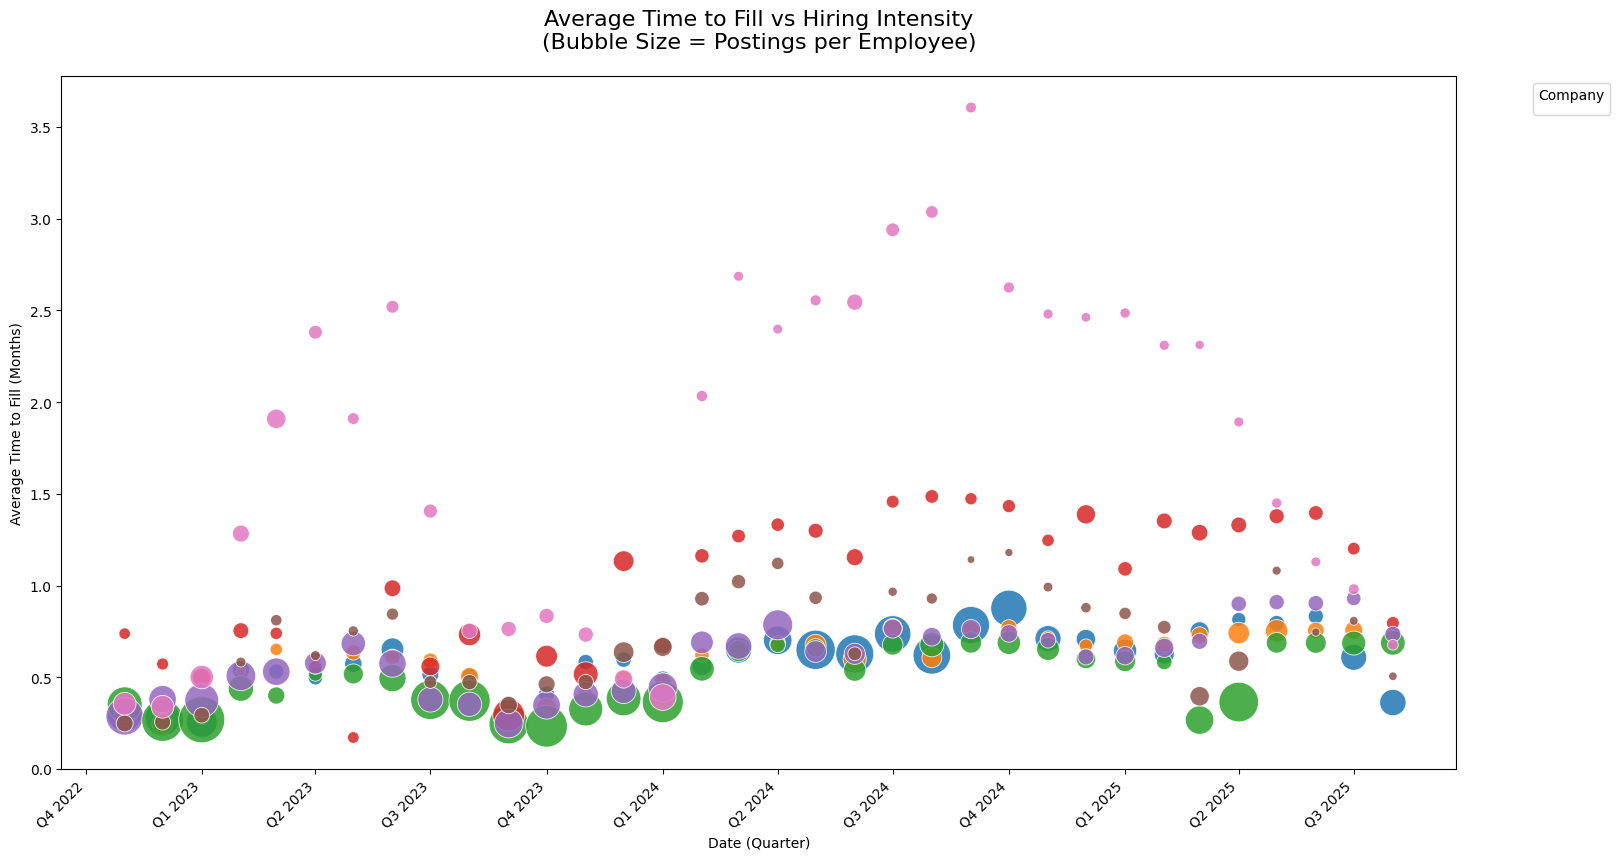

In [167]:
# Bubble Plot - NO size legend
plt.figure(figsize=(18, 9))

sns.scatterplot(
    data=total_df,
    x='date',
    y='Avg_time_to_fill',
    size='hiring_intensity',
    hue='company_name',
    sizes=(30, 1100),
    alpha=0.85,
    palette="tab10",
    legend=False          # ← This removes both automatic legends
)

ax = plt.gca()


# Quarterly x-axis
def quarter_formatter(x, pos):
    dt = mdates.num2date(x)
    q = (dt.month - 1) // 3 + 1
    return f'Q{q} {dt.year}'

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(FuncFormatter(quarter_formatter))
plt.xticks(rotation=45, ha='right')

plt.title("Average Time to Fill vs Hiring Intensity\n(Bubble Size = Postings per Employee)", fontsize=16, pad=20)
plt.xlabel("Date (Quarter)")
plt.ylabel("Average Time to Fill (Months)")

# Company color legend on the side (no size legend)
plt.legend(title="Company", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

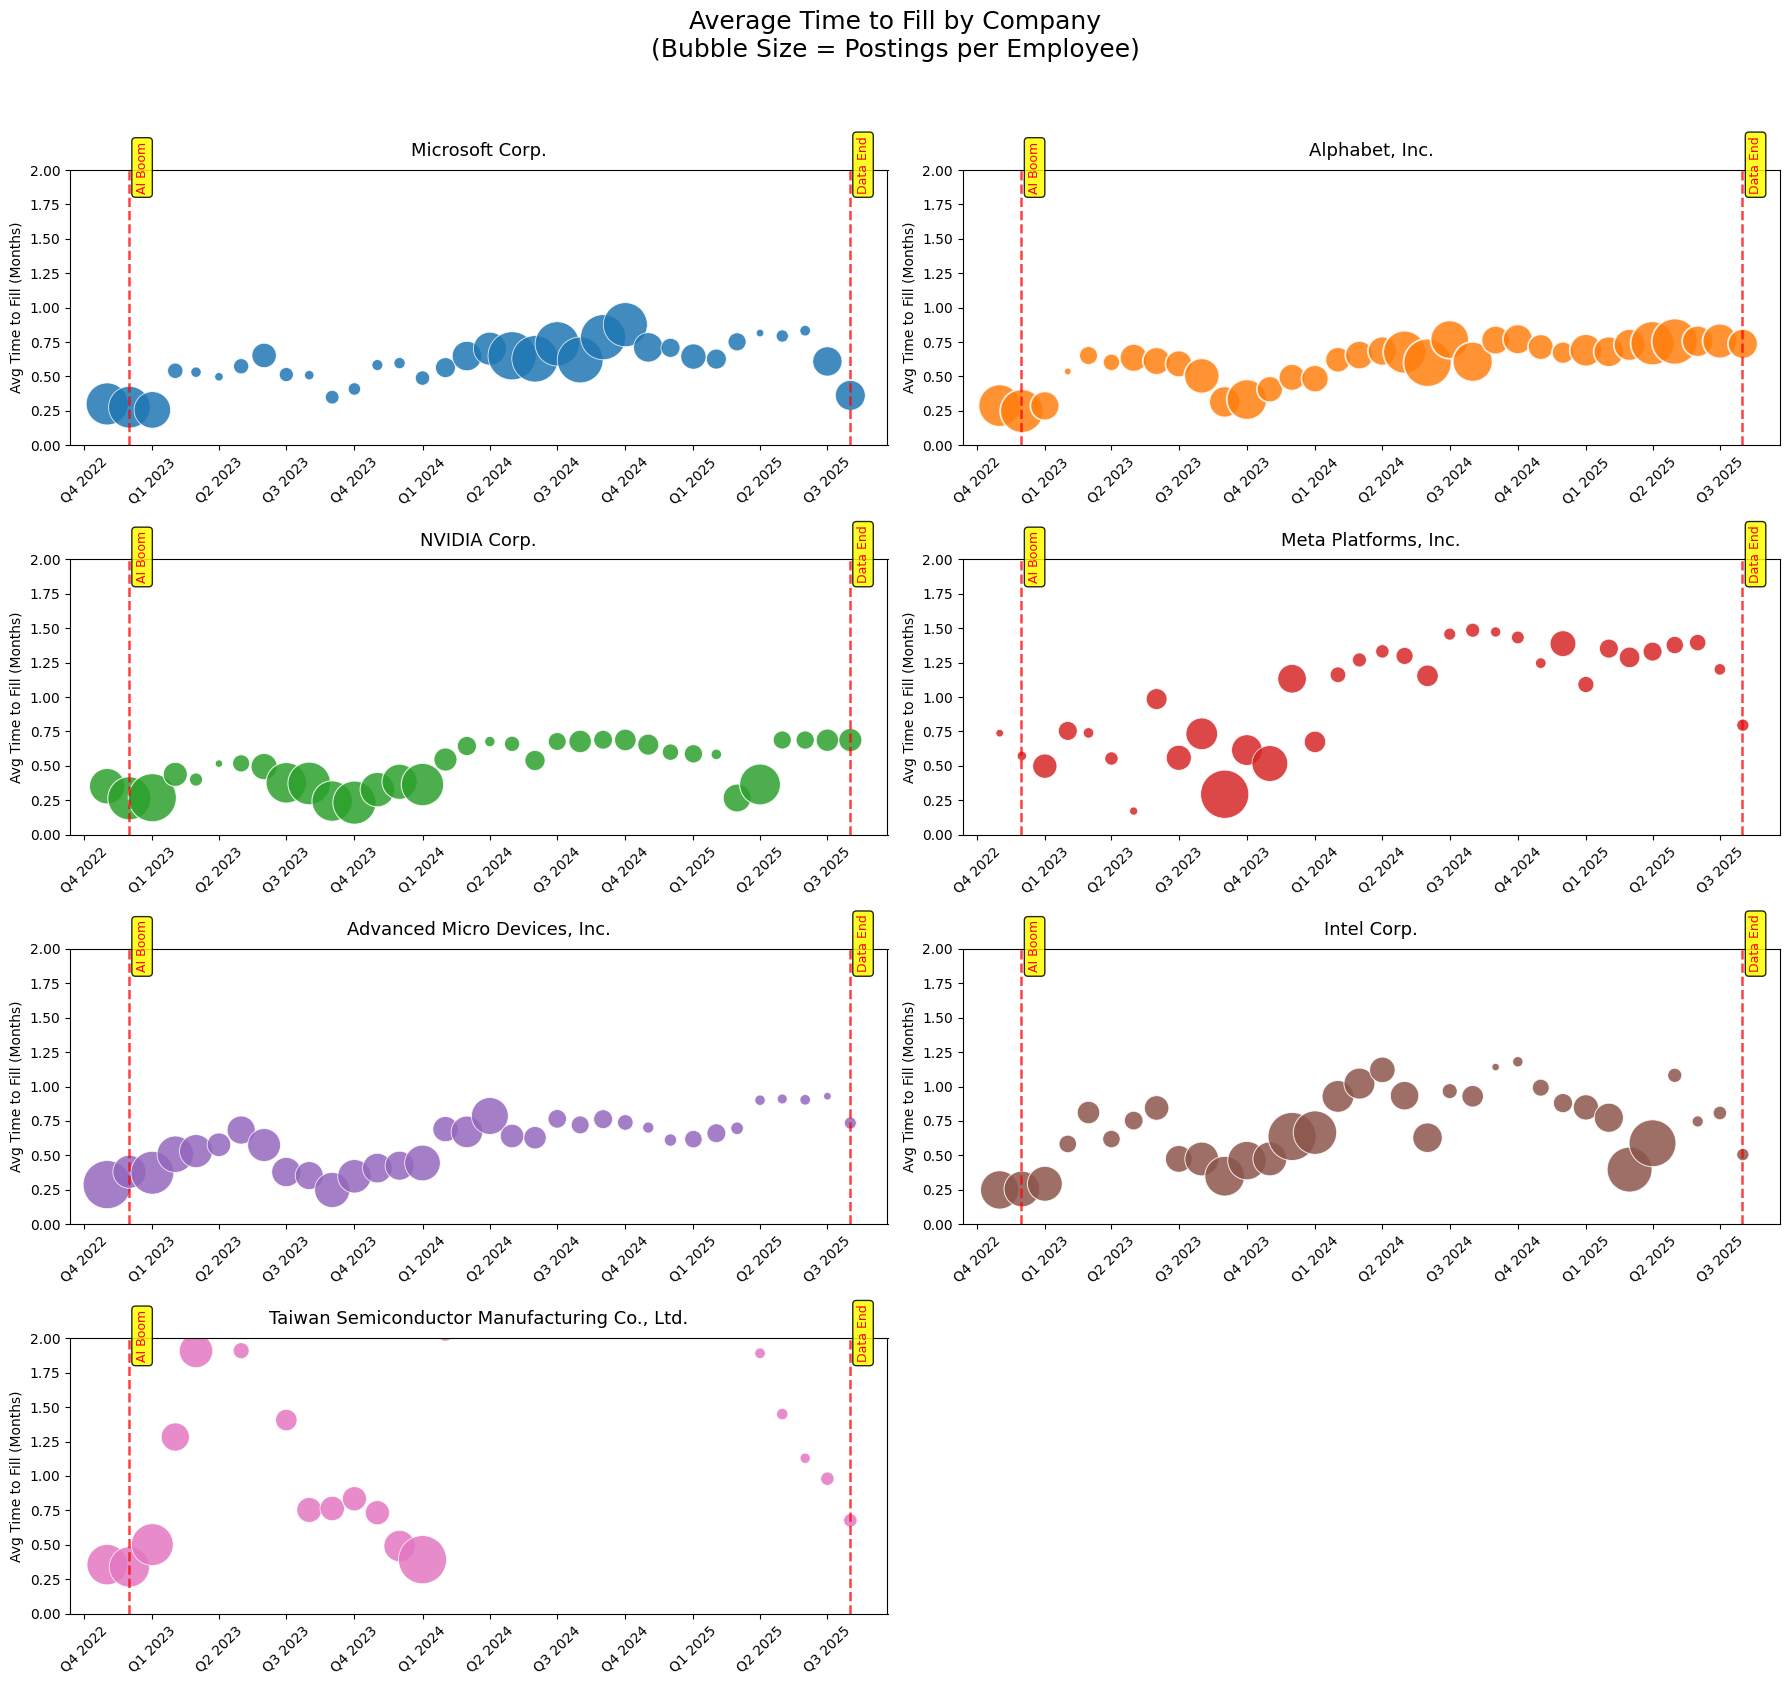

In [174]:

# === Subplots: one per company ===
companies = total_df['company_name'].unique()
n = len(companies)
nrows = 4
ncols = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 16), sharex=False, sharey=False)
axes = axes.flatten()

colors = plt.cm.tab10.colors  # same nice colors as before

for i, company in enumerate(companies):
    ax = axes[i]
    df_comp = total_df[total_df['company_name'] == company]
    
    sns.scatterplot(
        data=df_comp,
        x='date',
        y='Avg_time_to_fill',
        size='hiring_intensity',
        sizes=(30, 1200),
        alpha=0.85,
        color=colors[i % len(colors)],
        ax=ax,
        legend=False
    )
    ax.set_ylim(0, 2)
    ax.set_title(company, fontsize=13, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Avg Time to Fill (Months)")
    
    # Red vertical lines in every subplot
    for date, label in [
        ('2022-11-30', 'AI Boom'),
        ('2025-07-31', 'Data End')
    ]:
        ax.axvline(x=pd.to_datetime(date), color='red', linestyle='--', linewidth=1.8, alpha=0.75)
        ax.annotate(label, xy=(pd.to_datetime(date), ax.get_ylim()[1]*0.9),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, color='red', rotation=90,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.85))

    # Quarterly x-axis
    def quarter_formatter(x, pos):
        dt = mdates.num2date(x)
        q = (dt.month - 1) // 3 + 1
        return f'Q{q} {dt.year}'
    
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
    ax.xaxis.set_major_formatter(FuncFormatter(quarter_formatter))
    ax.tick_params(axis='x', rotation=45)

# Hide the last empty subplot (8th one)
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Average Time to Fill by Company\n(Bubble Size = Postings per Employee)", fontsize=18, y=1.05)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

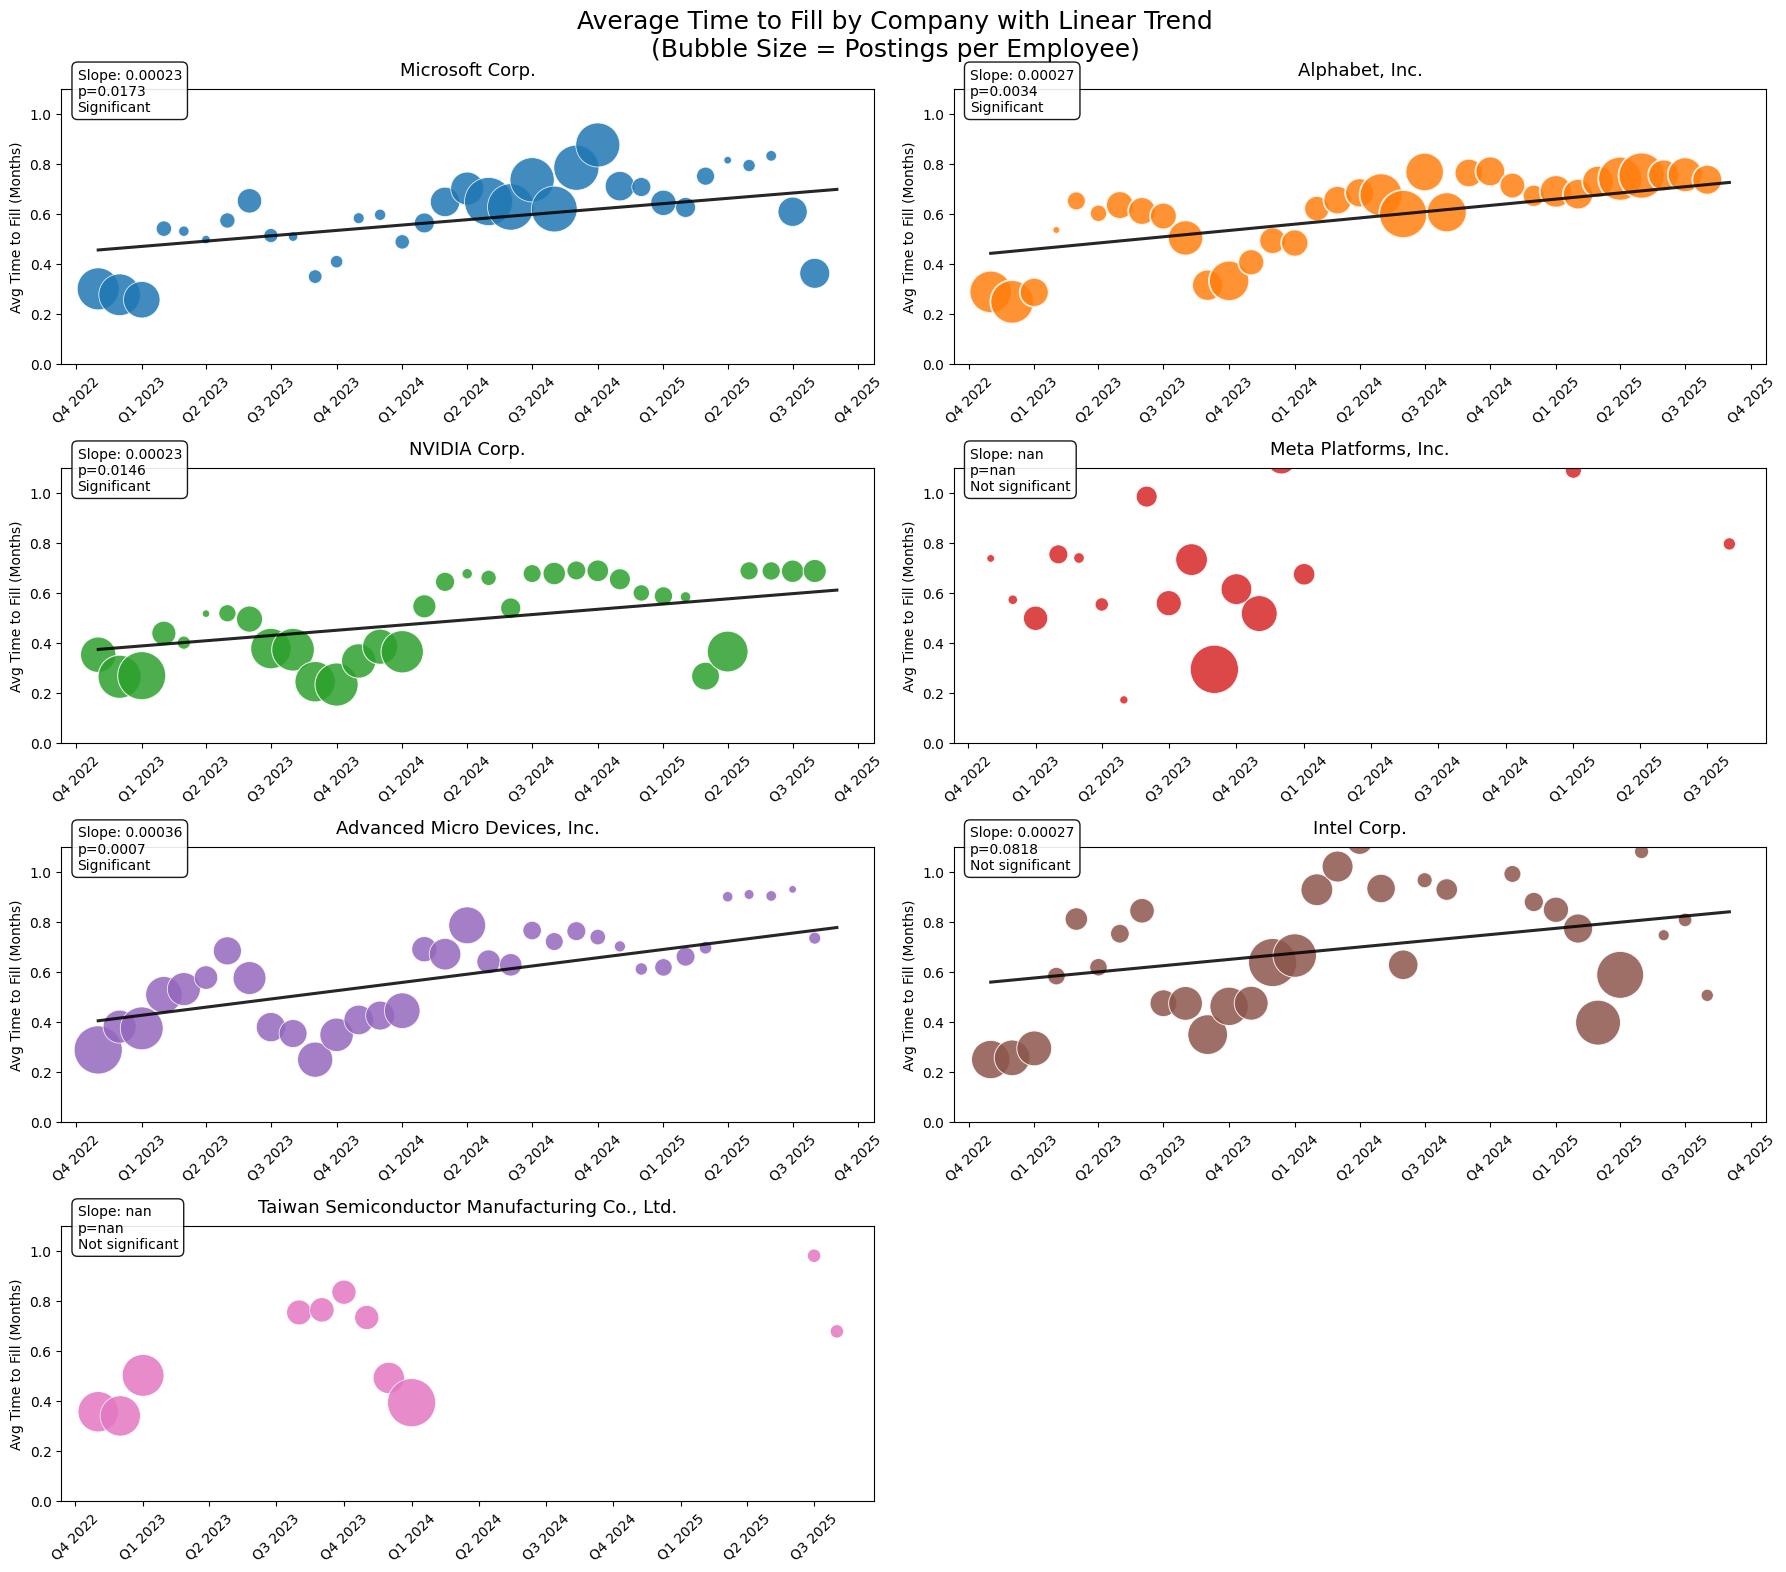

In [179]:

# === Subplots with regression lines (no vertical lines) ===
companies = total_df['company_name'].unique()
fig, axes = plt.subplots(4, 2, figsize=(18, 16), sharex=False, sharey=False)
axes = axes.flatten()

colors = plt.cm.tab10.colors

for i, company in enumerate(companies):
    ax = axes[i]
    df_comp = total_df[total_df['company_name'] == company].copy()
    
    # Bubble plot
    sns.scatterplot(
        data=df_comp,
        x='date',
        y='Avg_time_to_fill',
        size='hiring_intensity',
        sizes=(30, 1200),
        alpha=0.85,
        color=colors[i % len(colors)],
        ax=ax,
        legend=False
    )
    
    # Fixed y-range
    ax.set_ylim(0, 1.1)
    
    # Linear regression line + significance
    df_comp['time_num'] = (df_comp['date'] - df_comp['date'].min()).dt.days
    x = df_comp['time_num'].values
    y = df_comp['Avg_time_to_fill'].values
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    
    # Plot fitted line
    x_line = np.array([x.min(), x.max()])
    y_line = intercept + slope * x_line
    ax.plot(df_comp['date'].iloc[[0, -1]], y_line, color='black', linestyle='-', linewidth=2.2, alpha=0.85)
    
    # Significance annotation
    sig_text = "Significant" if p_value < 0.05 else "Not significant"
    ax.text(0.02, 0.92, f"Slope: {slope:.5f}\np={p_value:.4f}\n{sig_text}",
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9))
    
    ax.set_title(company, fontsize=13, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Avg Time to Fill (Months)")
    
    # Quarterly x-axis
    def quarter_formatter(x, pos):
        dt = mdates.num2date(x)
        q = (dt.month - 1) // 3 + 1
        return f'Q{q} {dt.year}'
    
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
    ax.xaxis.set_major_formatter(FuncFormatter(quarter_formatter))
    ax.tick_params(axis='x', rotation=45)

# Hide empty subplot
for j in range(len(companies), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Average Time to Fill by Company with Linear Trend\n(Bubble Size = Postings per Employee)", fontsize=18, y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

In [181]:
# === SUMMARY STATISTICS TABLE: Linear Trend in Avg Time to Fill ===
print("📊 LINEAR REGRESSION SUMMARY: Avg Time to Fill Trend per Company\n")

results = []
for company in total_df['company_name'].unique():
    df = total_df[total_df['company_name'] == company].copy()
    if len(df) < 3:
        continue
    
    df['time_num'] = (df['date'] - df['date'].min()).dt.days
    x = df['time_num'].values
    y = df['Avg_time_to_fill'].values
    
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    
    results.append({
        'Company': company,
        'Slope (months/day)': round(slope, 6),
        'Std. Error': round(std_err, 6),
        'p-value': round(p_value, 4),
        'R²': round(r_value**2, 4),
        'Significant (p < 0.05)': 'Yes' if p_value < 0.05 else 'No',
        'Observations': len(df)
    })

reg_summary = pd.DataFrame(results)
display(reg_summary.sort_values(by='p-value'))

📊 LINEAR REGRESSION SUMMARY: Avg Time to Fill Trend per Company



,Company,Slope (months/day),Std. Error,p-value,R²,Significant (p < 0.05),Observations
4,"Advanced Micro Devices, Inc.",0.000361,0.000097,0.0007,0.2973,Yes,35
1,"Alphabet, Inc.",0.000274,0.000087,0.0034,0.2314,Yes,35
2,NVIDIA Corp.,0.000229,0.000089,0.0146,0.1678,Yes,35
0,Microsoft Corp.,0.000234,0.000093,0.0173,0.1600,Yes,35
5,Intel Corp.,0.000272,0.000151,0.0818,0.0890,No,35
3,"Meta Platforms, Inc.",NaN,NaN,NaN,NaN,No,35
6,"Taiwan Semiconductor Manufacturing Co., Ltd.",NaN,NaN,NaN,NaN,No,35


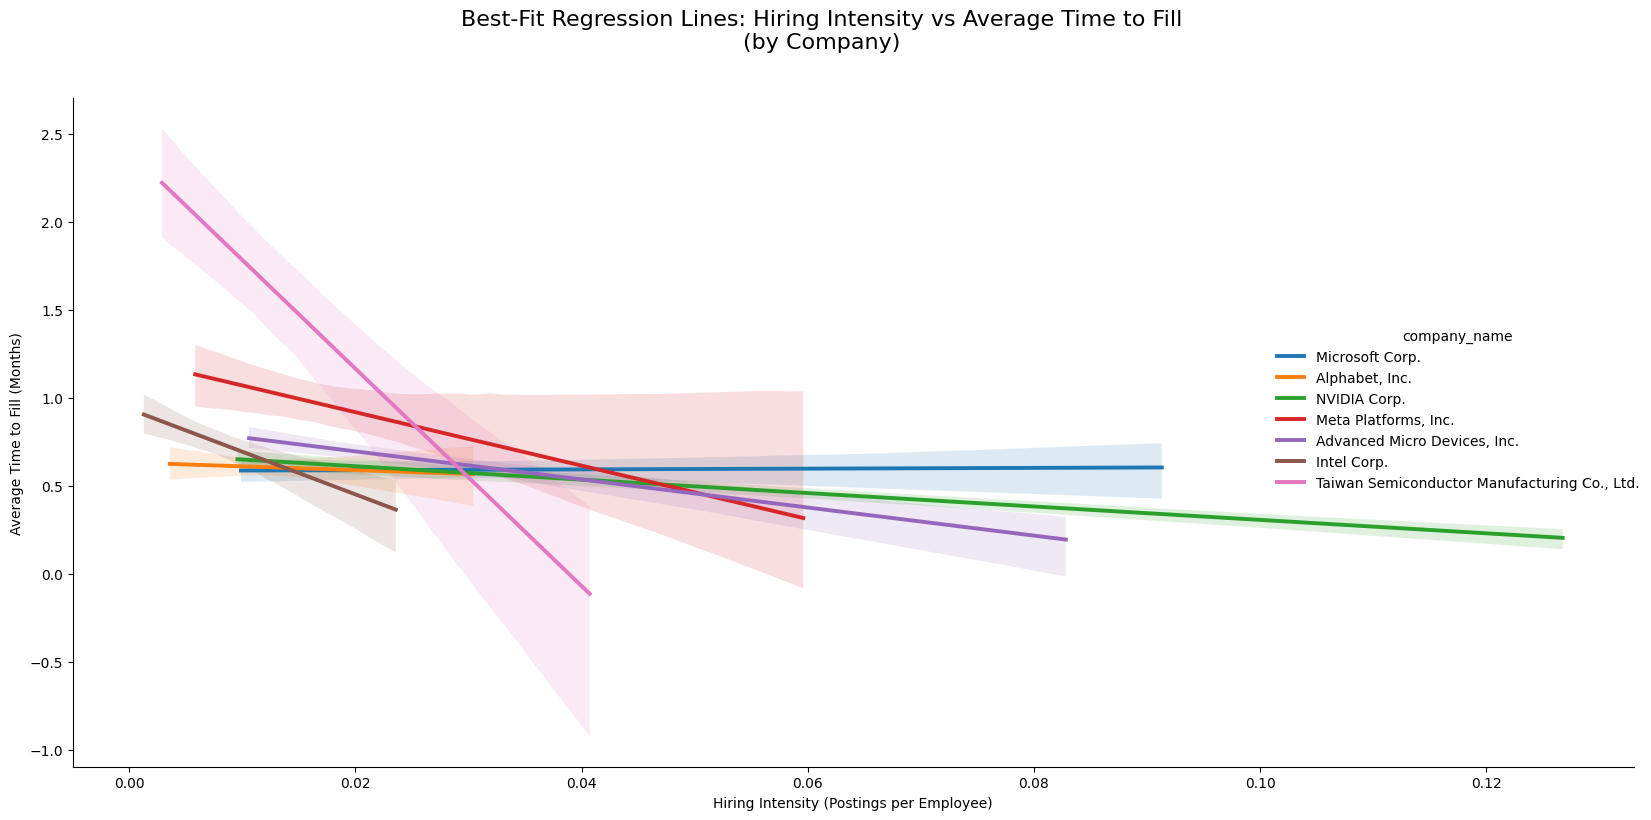

In [189]:
# Only regression lines (no scatter points)
g = sns.lmplot(
    data=total_df,
    x='hiring_intensity',
    y='Avg_time_to_fill',
    hue='company_name',
    scatter=False,                    # ← no points
    line_kws={'linewidth': 2.8},
    palette="tab10",
    height=8,
    aspect=1.6
)

g.set_axis_labels("Hiring Intensity (Postings per Employee)", "Average Time to Fill (Months)")
g.fig.suptitle("Best-Fit Regression Lines: Hiring Intensity vs Average Time to Fill\n(by Company)", 
               fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

In [193]:
# === Summary Statistics by Company ===
summary_stats = (
    total_df
    .groupby('company_name')
    .agg({
        'Avg_time_to_fill': ['count', 'mean', 'median', 'std', 'min', 'max'],
        'hiring_intensity': ['mean', 'median', 'std', 'min', 'max'],
        'total_postings': ['mean', 'sum'],
        'total_headcount': ['mean']
    })
    .round(3)
)

# Rename columns for clarity
summary_stats.columns = [
    'Num Months', 'Avg Fill (mean)', 'Avg Fill (median)', 'Avg Fill (std)', 
    'Avg Fill (min)', 'Avg Fill (max)',
    'Hiring Intensity (mean)', 'Hiring Intensity (median)', 
    'Hiring Intensity (std)', 'Hiring Intensity (min)', 'Hiring Intensity (max)',
    'Avg Postings per Month', 'Total Postings (all time)',
    'Avg Headcount'
]

print("✅ SUMMARY STATISTICS BY COMPANY")
display(summary_stats)

# Overall summary (all companies combined)
print("\n=== OVERALL (All 7 Companies) ===")
overall = total_df[['Avg_time_to_fill', 'hiring_intensity', 'total_postings', 'total_headcount']].describe().round(3)
display(overall)

# Correlation between Avg_time_to_fill and Hiring Intensity (per company)
print("\n=== Correlation: Avg Time to Fill vs Hiring Intensity (per company) ===")
corr_per_company = (
    total_df
    .groupby('company_name')
    .apply(lambda x: x['Avg_time_to_fill'].corr(x['hiring_intensity']))
    .round(3)
    .to_frame(name='Correlation')
)

display(corr_per_company)

✅ SUMMARY STATISTICS BY COMPANY


,Num Months,Avg Fill (mean),Avg Fill (median),Avg Fill (std),Avg Fill (min),Avg Fill (max),Hiring Intensity (mean),Hiring Intensity (median),Hiring Intensity (std),Hiring Intensity (min),Hiring Intensity (max),Avg Postings per Month,Total Postings (all time),Avg Headcount
company_name,,,,,,,,,,,,,,
"Advanced Micro Devices, Inc.",35,0.590,0.628,0.206,0.074,0.930,0.031,0.028,0.017,0.011,0.083,1598.429,55945,53875.957031
"Alphabet, Inc.",35,0.584,0.635,0.178,0.079,0.770,0.015,0.013,0.007,0.004,0.030,6018.200,210637,399451.812500
Intel Corp.,35,0.699,0.746,0.284,0.066,1.180,0.009,0.007,0.006,0.001,0.024,1465.200,51282,166822.718750
"Meta Platforms, Inc.",34,1.002,1.144,0.385,0.171,1.486,0.014,0.011,0.011,0.006,0.060,2541.229,88943,182700.343750
Microsoft Corp.,35,0.577,0.609,0.183,0.051,0.876,0.036,0.022,0.027,0.010,0.091,17578.457,615246,497263.406250
NVIDIA Corp.,35,0.492,0.518,0.175,0.066,0.690,0.048,0.033,0.034,0.010,0.127,2119.886,74196,46665.902344
"Taiwan Semiconductor Manufacturing Co., Ltd.",34,1.740,1.910,0.930,0.339,3.606,0.011,0.007,0.009,0.003,0.041,209.829,7344,20514.017578



=== OVERALL (All 7 Companies) ===


,Avg_time_to_fill,hiring_intensity,total_postings,total_headcount
count,243.000,238.000,245.000,238.000
mean,0.807,0.024,4504.461,195327.750
std,0.578,0.023,7711.600,172181.953
min,0.051,0.001,52.000,19231.232
25%,0.498,0.009,797.000,49483.301
50%,0.670,0.015,1868.000,168142.969
75%,0.846,0.029,4774.000,397136.562
max,3.606,0.127,45327.000,510336.594



=== Correlation: Avg Time to Fill vs Hiring Intensity (per company) ===


,Correlation
company_name,
"Advanced Micro Devices, Inc.",-0.736
"Alphabet, Inc.",-0.089
Intel Corp.,-0.574
"Meta Platforms, Inc.",-0.417
Microsoft Corp.,0.036
NVIDIA Corp.,-0.803
"Taiwan Semiconductor Manufacturing Co., Ltd.",-0.623


In [199]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Clean the data
df_reg = total_df.dropna(subset=['Avg_time_to_fill', 'total_headcount']).copy()
df_reg = df_reg[np.isfinite(df_reg['total_headcount']) & np.isfinite(df_reg['total_postings'])]
df_reg['hiring_intensity'] = df_reg['total_postings'] / df_reg['total_headcount']

print(f"✅ Cleaned data for regression: {len(df_reg)} rows remain")

# ====================== INDIVIDUAL REGRESSIONS PER COMPANY ======================
results = []

for name, group in df_reg.groupby('company_name'):
    X = sm.add_constant(group['hiring_intensity'])
    y = group['Avg_time_to_fill']
    
    model = sm.OLS(y, X).fit()
    
    results.append({
        'Company': name,
        'Num Months': len(group),
        'R-squared': round(model.rsquared, 4),
        'Adj R-squared': round(model.rsquared_adj, 4),
        'Intercept': round(model.params['const'], 4),
        'Intercept p-value': round(model.pvalues['const'], 4),
        'Slope (hiring_intensity)': round(model.params['hiring_intensity'], 4),
        'Slope p-value': round(model.pvalues['hiring_intensity'], 4),
        'F-statistic p-value': round(model.f_pvalue, 4)
    })

reg_summary = pd.DataFrame(results)

print("\n=== INDIVIDUAL REGRESSION SUMMARY: Avg_time_to_fill ~ hiring_intensity ===")
print("(One regression per company)\n")
display(reg_summary)

✅ Cleaned data for regression: 238 rows remain

=== INDIVIDUAL REGRESSION SUMMARY: Avg_time_to_fill ~ hiring_intensity ===
(One regression per company)



,Company,Num Months,R-squared,Adj R-squared,Intercept,Intercept p-value,Slope (hiring_intensity),Slope p-value,F-statistic p-value
0,"Advanced Micro Devices, Inc.",34,0.5424,0.5280,0.8547,0.0,-7.9689,0.0000,0.0000
1,"Alphabet, Inc.",34,0.0079,-0.0231,0.6318,0.0,-2.1484,0.6169,0.6169
2,Intel Corp.,34,0.3298,0.3088,0.9359,0.0,-24.2321,0.0004,0.0004
3,"Meta Platforms, Inc.",34,0.1741,0.1483,1.2213,0.0,-15.1708,0.0141,0.0141
4,Microsoft Corp.,34,0.0013,-0.0299,0.5845,0.0,0.2125,0.8390,0.8390
5,NVIDIA Corp.,34,0.6450,0.6339,0.6872,0.0,-3.8089,0.0000,0.0000
6,"Taiwan Semiconductor Manufacturing Co., Ltd.",34,0.3881,0.3690,2.3997,0.0,-61.7210,0.0001,0.0001
